## 0 · Setup

In [ ]:
!pip install rasterio imagecodecs scikit-image scikit-learn psutil -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 97.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/A_Thesis')

import os, glob, random, time
import numpy as np
import rasterio
import tensorflow as tf
import psutil
from skimage.util import random_noise

from utils_b import (
    fix_random_seeds, get_class_weights, softmax_with_temperature,
    CustomMacroF1Score, custom_categorical_crossentropy,
)
from resunet import res_unet

fix_random_seeds(42)
print('TF:', tf.__version__)

TF: 2.19.0


## 1 · Configuration

## Run 36 (extended historical context) - Baseline notebook with functionality for all runs with temporal information

| Parameter | Run 31 | Run 36 |
|---|---|---|
| Val AOIs | AOI_2 | AOI_2 |
| Test AOIs | AOI_4, AOI_5 | AOI_4, AOI_5 (held-out) |




In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DRIVE_ROOT = '/content/drive/MyDrive'
IMG_ROOT   = os.path.join(DRIVE_ROOT, 'Final_GEE_Exports')
GT_ROOT    = os.path.join(DRIVE_ROOT,
             'GEE_Exports quarter_only/Driver_test/clipped_outputs')
DATA_DIR        = '/content/data'
EXP_DIR         = '/content/exp'
DRIVE_CACHE_DIR = os.path.join(DRIVE_ROOT, 'numpy_cache')

ALL_AOIS         = [f'AOI_{i}' for i in range(13) if i not in (1, 8, 9)]
REQUIRED_DRIVERS = {1, 2, 3}


TRAIN_INCOMPLETE_AOIS = ['AOI_0', 'AOI_10', 'AOI_11', 'AOI_12']
TRAIN_AOIS_MANUAL     = ['AOI_7','AOI_6','AOI_3']
VAL_AOIS_MANUAL       = ['AOI_2']
TEST_AOIS_MANUAL      = ['AOI_4','AOI_5'] # held-out — never seen during training

# ── Temporal extent ───────────────────────────────────────────────────────────
GT_YEAR            = 2024
YEARS_BEFORE       = 2
INCLUDE_YEAR_AFTER = True

# ── Temporal resolution ───────────────────────────────────────────────────────
TEMPORAL_RES = 's2_quarterly'

# ── Band selection ────────────────────────────────────────────────────────────
ALL_BAND_NAMES = ['B3', 'B4', 'B8', 'B12', 'VV', 'VH']
SELECTED_BANDS = None
NB_CLASSES     = 3   # 0=bark-beetle, 1=mgmt, 2=wind-throw

# ── Hyperparameters
SIZE_CROPS            = 128
BATCH_SIZE            = 4
N_SAMPLES_TRAIN       = 3200
N_SAMPLES_VAL         = 1600
EPOCHS                = 14
BASE_LR               = 1e-4
FINAL_LR              = 1e-6
TEMPERATURE           = 15
AUGMENT               = True
AUGMENT_ROTATE        = True
DIST_CENTER_PROB      = 0.80
WIND_THROW_OVERSAMPLE = 0.15
WEIGHT_DECAY          = 2e-4
LR_SCHEDULE           = 'cosine'

for d in [DATA_DIR, EXP_DIR,
          os.path.join(DATA_DIR, 'train'),
          os.path.join(DATA_DIR, 'val'),
          os.path.join(DATA_DIR, 'test')]:
    os.makedirs(d, exist_ok=True)

print('Config OK — Run 34')
print(f'  VAL  : {VAL_AOIS_MANUAL}')
print(f'  TEST : {TEST_AOIS_MANUAL}  (held-out)')
print(f'  TRAIN: {TRAIN_AOIS_MANUAL} + {TRAIN_INCOMPLETE_AOIS}')


Config OK — Run 34
  VAL  : ['AOI_2']
  TEST : ['AOI_4', 'AOI_5']  (held-out)
  TRAIN: ['AOI_7', 'AOI_6', 'AOI_3'] + ['AOI_0', 'AOI_10', 'AOI_11', 'AOI_12']


## 2 · Temporal Parameters


In [ ]:
# ── Year list ─────────────────────────────────────────────────────────────────
pre_years  = [GT_YEAR - (YEARS_BEFORE - i) for i in range(YEARS_BEFORE)]
post_years = [GT_YEAR + 1] if INCLUDE_YEAR_AFTER else []
ALL_YEARS  = pre_years + [GT_YEAR] + post_years   # GT_YEAR always included
print(f'Years in window : {ALL_YEARS}  (GT: {GT_YEAR})')

# ── Monthly labels — exact filenames to load from Drive ─────────────────────
# For most modes every month is needed.
# For 's2_quarterly' only M02/M05/M08/M11 are needed — build the list

_S2Q_MONTHS = [2, 5, 8, 11]
if TEMPORAL_RES == 's2_quarterly':
    MONTH_LABELS_RAW = [f'{yr}_M{m:02d}'
                        for yr in ALL_YEARS for m in _S2Q_MONTHS]
else:
    MONTH_LABELS_RAW = [f'{yr}_M{m:02d}'
                        for yr in ALL_YEARS for m in range(1, 13)]
print(f'Monthly labels  : {MONTH_LABELS_RAW[:3]} … {MONTH_LABELS_RAW[-3:]}  '
      f'({len(MONTH_LABELS_RAW)} total)')

# ── Timestep groups ───────────────────────────────────────────────────────────
# Each group is a list of month-indices whose arrays are averaged into one timestep.
def _make_groups(n_months, res):
    if res == 'monthly':
        return [[i] for i in range(n_months)]
    elif res == 'quarterly':
        groups = []
        for y in range(n_months // 12):
            base = y * 12
            for q in range(4):
                groups.append([base + q*3 + k for k in range(3)])
        return groups
    elif res == 'annual':
        return [[y*12 + k for k in range(12)] for y in range(n_months // 12)]
    elif res == 's2_quarterly':

        return [[i] for i in range(n_months)]

TIMESTEP_GROUPS = _make_groups(len(MONTH_LABELS_RAW), TEMPORAL_RES)
N_TIMESTEPS     = len(TIMESTEP_GROUPS)
print(f'Temporal res    : {TEMPORAL_RES}  →  {N_TIMESTEPS} timesteps')

# ── Band indices ──────────────────
if SELECTED_BANDS is None:
    BAND_INDICES   = list(range(len(ALL_BAND_NAMES)))
    BAND_NAMES_USED = ALL_BAND_NAMES
else:
    for b in SELECTED_BANDS:
        if b not in ALL_BAND_NAMES:
            raise ValueError(f'Band {b!r} not in ALL_BAND_NAMES {ALL_BAND_NAMES}')
    BAND_INDICES    = [ALL_BAND_NAMES.index(b) for b in SELECTED_BANDS]
    BAND_NAMES_USED = SELECTED_BANDS

N_BANDS        = len(BAND_INDICES)
TOTAL_CHANNELS = N_BANDS * N_TIMESTEPS   # input channels into the model

# ── Steps per epoch ───────────────
STEPS_PER_EPOCH  = N_SAMPLES_TRAIN // BATCH_SIZE
VALIDATION_STEPS = N_SAMPLES_VAL   // BATCH_SIZE

print(f'Bands           : {BAND_NAMES_USED}  ({N_BANDS} bands)')
print(f'Total channels  : {N_BANDS} × {N_TIMESTEPS} = {TOTAL_CHANNELS}')
print(f'Steps/epoch     : {STEPS_PER_EPOCH}  |  val steps: {VALIDATION_STEPS}')

# ── Cache tag — unique key for every combination of temporal/band config
# Changing YEARS_BEFORE, INCLUDE_YEAR_AFTER, TEMPORAL_RES or SELECTED_BANDS
# produces a different tag, so a fresh set of .npy files is created on Drive.
_bands_tag = 'allbands' if SELECTED_BANDS is None else '+'.join(SELECTED_BANDS)
_post_tag  = 'post' if INCLUDE_YEAR_AFTER else 'npost'
CACHE_TAG  = f'{YEARS_BEFORE}yr{_post_tag}_{TEMPORAL_RES}_{_bands_tag}'
print(f'Cache tag       : {CACHE_TAG}')

Years in window : [2022, 2023, 2024, 2025]  (GT: 2024)
Monthly labels  : ['2022_M02', '2022_M05', '2022_M08'] … ['2025_M05', '2025_M08', '2025_M11']  (16 total)
Temporal res    : s2_quarterly  →  16 timesteps
Bands           : ['B3', 'B4', 'B8', 'B12', 'VV', 'VH']  (6 bands)
Total channels  : 6 × 16 = 96
Steps/epoch     : 800  |  val steps: 400
Cache tag       : 2yrpost_s2_quarterly_allbands


## 3 · Helper Functions

In [ ]:
def _normalise_band(arr_2d):
    """
    Per-band robust normalisation to [0, 1].
    Clips to [2nd, 98th] percentile before scaling — more robust than
    /max for uint16 imagery where rare bright pixels crush the dynamic range.
    """
    p2, p98 = np.percentile(arr_2d, 2), np.percentile(arr_2d, 98)
    if p98 <= p2:
        return np.zeros_like(arr_2d, dtype=np.float32)
    return np.clip((arr_2d.astype(np.float32) - p2) / (p98 - p2), 0.0, 1.0)


def load_monthly_stack_raw(aoi, img_root, month_labels, drive_root=DRIVE_ROOT):
    """
    Load all monthly TIF composites for one AOI directly from Drive.
    Same I/O approach as Protocol 1 — no rsync, no local SSD.

    Returns
    -------
    stack : (T_monthly, H, W, B_all)  uint16
    loaded_labels : list[str]  — labels actually found (missing months zero-filled)
    """
    #####################################
    aoi_folder = os.path.join(DRIVE_ROOT, f'Final_GEE_Exports {aoi}')
    images, loaded_labels = [], []

    for label in month_labels:
        fpath = os.path.join(aoi_folder, f'{aoi}_{label}.tif')
        if not os.path.exists(fpath):
            continue
        with rasterio.open(fpath) as src:
            arr = src.read().transpose(1, 2, 0).astype(np.uint16)
        images.append(arr)
        loaded_labels.append(label)
    if not images:
        raise FileNotFoundError(
            f'No composites found for {aoi} in {aoi_folder}')
    stack = np.stack(images, axis=0)   # (T, H, W, B)
    print(f'  [{aoi}] loaded {len(images)} months → {stack.shape}')
    return stack, loaded_labels

    # Remove leading zero
    valid_images = [im for im in images if not np.all(im == 0)]
    if not valid_images:
        raise FileNotFoundError(
            f'No composites found for {aoi} in {aoi_folder}')

    # replace any zero-fill placeholders that have wrong shape
    H, W, B = valid_images[0].shape
    final = []
    vi = 0
    for im in images:
        if np.all(im == 0) and im.shape != (H, W, B):
            final.append(np.zeros((H, W, B), dtype=np.uint16))
        else:
            final.append(im)

    stack = np.stack(final, axis=0)   # (T, H, W, B)
    print(f'  [{aoi}] loaded {len(final)} months → {stack.shape}  dtype={stack.dtype}')
    return stack, loaded


def aggregate_and_normalise(stack_monthly, timestep_groups, band_indices):
    """
    Aggregate monthly stack to chosen temporal resolution, select bands,
    and normalise each band independently via percentile stretch.

    Parameters
    ----------
    stack_monthly  : (T_monthly, H, W, B_all)  uint16
    timestep_groups: list[list[int]]  month indices averaged per output timestep
    band_indices   : list[int]        band positions to keep

    Returns
    -------
    result : (T_out, H, W, B_sel)  float32  [0, 1]
    """
    T_monthly, H, W, _ = stack_monthly.shape
    T_out  = len(timestep_groups)
    B_sel  = len(band_indices)
    result = np.empty((T_out, H, W, B_sel), dtype=np.float16)

    for t, idx_list in enumerate(timestep_groups):
        # Average the months in this group, select bands
        group  = stack_monthly[idx_list][:, :, :, band_indices].astype(np.float32)
        mean_t = group.mean(axis=0)                         # (H, W, B_sel)
        for b in range(B_sel):
            result[t, :, :, b] = _normalise_band(mean_t[:, :, b]).astype(np.float16)

    return result   # (T_out, H, W, B_sel)  float16  [0, 1]


def load_gt(aoi, gt_root):
    """
    Load GT and remap to 0-indexed 3-class labels.  Identical to Protocol 1.

    Raw GT → stored:
      0 (background) → 255  ignored by loss
      1 (bark-beetle)→   0  model output channel 0
      2 (mgmt/fire)  →   1  model output channel 1
      3 (wind-throw) →   2  model output channel 2
      255 (nodata)   → 255  ignored
    """
    gt_path = os.path.join(gt_root, f'{aoi}_drivers.tif')
    with rasterio.open(gt_path) as src:
        raw = src.read(1).astype(np.int16)
    gt           = np.full_like(raw, 255, dtype=np.uint8)
    gt[raw == 1] = 0
    gt[raw == 2] = 1
    gt[raw == 3] = 2
    counts  = {c: int((gt == c).sum()) for c in [0, 1, 2]}
    n_valid = sum(counts.values())
    print(f'  [{aoi}] GT {gt.shape}  driver px: {n_valid:,}  '
          f'bb={counts[0]:,} mgmt={counts[1]:,} wt={counts[2]:,}')
    return gt


def align_gt_to_image(stack, gt, aoi):
    """Crop/pad GT to match image spatial dims (GEE CRS rounding fix)."""

    H_img, W_img = stack.shape[1], stack.shape[2]
    H_gt,  W_gt  = gt.shape
    if (H_gt, W_gt) == (H_img, W_img):
        return gt
    h = min(H_img, H_gt);  w = min(W_img, W_gt)
    gt = gt[:h, :w]
    if h < H_img or w < W_img:
        gt = np.pad(gt, ((0, H_img-h), (0, W_img-w)), constant_values=255)
    print(f'    [{aoi}] spatial fix: GT({H_gt},{W_gt}) → img({H_img},{W_img})')
    return gt


def audit_aoi_drivers(gt_root, all_aois, required=None):
    """Return (complete_aois, incomplete_list) — checks Drive GT TIFs directly."""
    if required is None:
        required = {1, 2, 3}
    complete, incomplete = [], []
    for aoi in all_aois:
        # Check Drive TIF first, then fall back to any saved .npy
        candidates = [
            os.path.join(gt_root, f'{aoi}_drivers.tif'),
            os.path.join(DATA_DIR, 'train', f'{aoi}_gt.npy'),
            os.path.join(DATA_DIR, 'val',   f'{aoi}_gt.npy'),
            os.path.join(DATA_DIR, 'test',  f'{aoi}_gt.npy'),
        ]
        gt_path = next((p for p in candidates if os.path.exists(p)), None)
        if gt_path is None:
            print(f'    {aoi}: no GT file found')
            incomplete.append((aoi, required))
            continue
        if gt_path.endswith('.tif'):
            with rasterio.open(gt_path) as src:
                arr = src.read(1).astype(np.int16)
            present = set(int(v) for v in np.unique(arr) if v not in (0, 255))
        else:
            arr     = np.load(gt_path).astype(np.int16)
            # .npy labels are 0-indexed — shift back for required check
            present = {v+1 for v in np.unique(arr) if v in (0, 1, 2)}
        missing = required - present
        if missing:
            incomplete.append((aoi, missing))
        else:
            complete.append(aoi)
    return complete, incomplete

print('Helper functions defined.')

Helper functions defined.


## 4 · RAM Cache + Dataloader

`build_ram_cache()` loads every `.npy` into RAM and precomputes disturbance
pixel coordinates — identical to Protocol 1.

`FastCropDataset` is the only cell that differs from Protocol 1:
- Cache stores `(T, H, W, B)` stacks instead of `(H, W, B)` mean composites  
- Generator crops `(T, tile, tile, B)` then reshapes to `(tile, tile, T×B)`

In [ ]:
IMG_CACHE  = {}   # {img_path → (T, H, W, B) float32}  full temporal stack
GT_CACHE   = {}   # {gt_path  → (H, W) uint8}           0-indexed labels
DIST_CACHE = {}   # {gt_path  → (valid_ys, valid_xs)}   precomputed centres


def build_ram_cache(img_paths, gt_paths, tile_size):
    """
    Load every AOI .npy into RAM once per session.
    Identical to Protocol 1 except IMG_CACHE stores the full (T,H,W,B)
    stack — NOT a mean — so the temporal axis is preserved for stacking.
    """
    global IMG_CACHE, GT_CACHE, DIST_CACHE
    IMG_CACHE.clear(); GT_CACHE.clear(); DIST_CACHE.clear()

    half     = tile_size // 2
    total_mb = 0
    t0       = time.time()

    for img_path, gt_path in zip(img_paths, gt_paths):
        aoi = os.path.basename(img_path).replace('_input.npy', '')
        t1  = time.time()

        stack = np.load(img_path)    # (T, H, W, B) float32
        gt    = np.load(gt_path)     # (H, W) uint8

        IMG_CACHE[img_path] = stack
        GT_CACHE[gt_path]   = gt

        # Precompute valid disturbance-centre pixels (0-indexed classes)
        H, W   = gt.shape
        ys, xs = np.where(np.isin(gt, [0, 1, 2]))
        valid  = ((ys >= half) & (ys < H - half) &
                  (xs >= half) & (xs < W - half))
        DIST_CACHE[gt_path] = (ys[valid].copy(), xs[valid].copy())

        mb        = (stack.nbytes + gt.nbytes) / 1e6
        total_mb += mb
        print(f'  {aoi}: {stack.shape}  {mb:.0f} MB  '
              f'dist centres: {valid.sum():,}  ({time.time()-t1:.1f}s)')

    avail = psutil.virtual_memory().available / 1e6
    print(f'\n✓ Cached {len(IMG_CACHE)} AOIs in {time.time()-t0:.1f}s  '
          f'| {total_mb:.0f} MB used  | {avail:.0f} MB remaining')


class FastCropDataset(tf.data.Dataset):
    """
    RAM-backed crop dataset for Protocol 2.

    Identical to Protocol 1 except:
    - IMG_CACHE holds (T, H, W, B) instead of (H, W, B)
    - After cropping, (T, tile, tile, B) is reshaped to (tile, tile, T*B)
    - Augmentation noise loops over T to hit all timesteps
    """

    def __new__(cls, image_paths, gt_paths,
                tile_size, batch_size, total_channels,
                n_bands_per_ts, samples, augment):

        def generator():
            n = len(image_paths)
            for _ in range(samples):
                i        = np.random.randint(0, n)
                img_path = image_paths[i]
                gt_path  = gt_paths[i]

                # ── RAM lookup — zero disk I/O ────────────────────────────
                stack = IMG_CACHE[img_path]    # (T, H, W, B)
                gt    = GT_CACHE[gt_path]      # (H, W)
                T, H, W, B = stack.shape

                # ── Spatial reconciliation (defensive guard) ──────────────
                if (H, W) != gt.shape:
                    h = min(H, gt.shape[0]);  w = min(W, gt.shape[1])
                    stack = stack[:, :h, :w, :];  gt = gt[:h, :w]
                    H, W  = h, w

                # ── Pad if AOI smaller than tile ──────────────────────────
                if H < tile_size or W < tile_size:
                    ph = max(0, tile_size - H)
                    pw = max(0, tile_size - W)
                    stack = np.pad(stack, ((0,0),(0,ph),(0,pw),(0,0)))
                    gt    = np.pad(gt,    ((0,ph),(0,pw)), constant_values=255)
                    H, W  = stack.shape[1], stack.shape[2]

                # ── Disturbance-centred crop (precomputed indices) ────────
                half     = tile_size // 2
                dys, dxs = DIST_CACHE[gt_path]
                ok       = ((dys >= half) & (dys < H - half) &
                            (dxs >= half) & (dxs < W - half))
                dys, dxs = dys[ok], dxs[ok]

                # adding extra random skew of the disturbed pixel so the system does not learn that disturbed pixel is always in the middle
                o = min(60, tile_size // 2 - 1)  #never exceeds half crop


                _wt_ys, _wt_xs = np.array([]), np.array([])
                if len(dys) > 0:
                    _wt_mask = (gt[dys, dxs] == 2)
                    if _wt_mask.any():
                        _wt_ys = dys[_wt_mask]
                        _wt_xs = dxs[_wt_mask]
                _force_wt = (len(_wt_ys) > 0 and random.random() < WIND_THROW_OVERSAMPLE)

                if _force_wt:
                    k = np.random.randint(0, len(_wt_ys))
                    r = int(np.clip(_wt_ys[k] - half + random.randint(-o, o), 0, H - tile_size))
                    c = int(np.clip(_wt_xs[k] - half + random.randint(-o, o), 0, W - tile_size))
                elif len(dys) > 0 and random.random() < DIST_CENTER_PROB:

                    k = np.random.randint(0, len(dys))
                    r = int(np.clip(dys[k] - half + random.randint(-o, o), 0, H - tile_size))
                    c = int(np.clip(dxs[k] - half + random.randint(-o, o), 0, W - tile_size))
                else:
                    r = np.random.randint(0, max(1, H - tile_size + 1))
                    c = np.random.randint(0, max(1, W - tile_size + 1))

                # ── Crop all timesteps ────────────────────────────────────
                crop_stk = stack[:, r:r+tile_size, c:c+tile_size, :]  # (T,tile,tile,B)
                crop_ref = gt[r:r+tile_size, c:c+tile_size].copy().astype(np.float32)

                if np.all(crop_ref == 255):
                    continue

                # ── Stack timesteps as channels: (T,H,W,B)→(H,W,T*B) ─────
                T_, H_, W_, B_ = crop_stk.shape
                crop_img = crop_stk.transpose(1, 2, 0, 3).reshape(H_, W_, T_ * B_)
                crop_img = crop_img.astype(np.float32)

                # ── Augmentation ──────────────────────────────────────────
                if augment:
                    if random.random() < 0.5:
                        crop_img = np.fliplr(crop_img);  crop_ref = np.fliplr(crop_ref)
                    if random.random() < 0.5:
                        crop_img = np.flipud(crop_img);  crop_ref = np.flipud(crop_ref)

                    if AUGMENT_ROTATE and random.random() < 0.75:
                        k = random.randint(1, 3)
                        crop_img = np.rot90(crop_img, k, axes=(0, 1)).copy()
                        crop_ref = np.rot90(crop_ref, k, axes=(0, 1)).copy()

                    if random.random() < 0.4:
                        from scipy.ndimage import map_coordinates, gaussian_filter
                        _sh = crop_img.shape[:2]
                        _dx = gaussian_filter(np.random.randn(*_sh).astype(np.float32), sigma=4) * 6
                        _dy = gaussian_filter(np.random.randn(*_sh).astype(np.float32), sigma=4) * 6
                        _x, _y = np.meshgrid(np.arange(_sh[1]), np.arange(_sh[0]))
                        _xi = np.clip(_x + _dx, 0, _sh[1]-1).astype(np.float32)
                        _yi = np.clip(_y + _dy, 0, _sh[0]-1).astype(np.float32)
                        _coords = [_yi.ravel(), _xi.ravel()]
                        for _ch in range(crop_img.shape[2]):
                            crop_img[..., _ch] = map_coordinates(
                                crop_img[..., _ch], _coords, order=1).reshape(_sh)
                        crop_ref = map_coordinates(
                            crop_ref, _coords, order=0).reshape(_sh)
                    if random.random() < 0.3:
                        # Gaussian noise on optical bands only (first 4 per timestep)
                        n_opt = min(4, B_ - 2)   # exclude last 2 bands (VV, VH)
                        if n_opt > 0:
                          for t_i in range(T_):
                            s = t_i * B_
                            crop_img[..., s:s+n_opt] = random_noise(
                                crop_img[..., s:s+n_opt],
                                mode='gaussian', clip=True).astype(np.float32)

                yield crop_img, crop_ref

        output_sig = (
            tf.TensorSpec(shape=(tile_size, tile_size, total_channels), dtype=tf.float32),
            tf.TensorSpec(shape=(tile_size, tile_size),                  dtype=tf.float32),
        )
        ds = tf.data.Dataset.from_generator(generator, output_signature=output_sig)
        return ds.batch(batch_size).repeat().prefetch(tf.data.AUTOTUNE)

print('RAM cache + dataloader defined.')

RAM cache + dataloader defined.


## 5 · AOI Driver Audit

In [ ]:
print(IMG_ROOT)


/content/drive/MyDrive/Final_GEE_Exports


In [ ]:
complete_aois, incomplete_aois = audit_aoi_drivers(GT_ROOT, ALL_AOIS, REQUIRED_DRIVERS)
print(f'   Complete   ({len(complete_aois)}): {complete_aois}')
print(f'   Incomplete ({len(incomplete_aois)}):')

for aoi, miss in incomplete_aois:
    print(f'      {aoi}  — missing raw classes: {miss}')

# ── Manual + auto split ───────────────────────────────────────────────────────
# Manual lists are always included in their split.
# Remaining complete AOIs (not manually assigned) are auto-split 60/20/20.
manual_assigned = set(TRAIN_AOIS_MANUAL) | set(VAL_AOIS_MANUAL) | set(TEST_AOIS_MANUAL)
auto_pool       = [a for a in complete_aois if a not in manual_assigned]

for aoi in manual_assigned:
    if aoi not in complete_aois:
        print(f'   Manually assigned {aoi} is incomplete — check audit above')

random.seed(42)
random.shuffle(auto_pool)
n_auto  = len(auto_pool)
n_train = max(0, round(n_auto * 0.60))
n_val   = max(0, round(n_auto * 0.20))

train_aois = TRAIN_AOIS_MANUAL + TRAIN_INCOMPLETE_AOIS + auto_pool[:n_train]
val_aois   = VAL_AOIS_MANUAL   + auto_pool[n_train:n_train + n_val]
test_aois  = TEST_AOIS_MANUAL  + auto_pool[n_train + n_val:]

print(f'\n  → TRAIN ({len(train_aois)}): {train_aois}')
print(f'  → VAL   ({len(val_aois)}):   {val_aois}')
print(f'  → TEST  ({len(test_aois)}):  {test_aois}')

for a, b, lbl in [(train_aois, val_aois,  'train/val'),
                  (train_aois, test_aois, 'train/test'),
                  (val_aois,   test_aois, 'val/test')]:
    ov = set(a) & set(b)
    print(f'  {"  OVERLAP" if ov else " no overlap"} {lbl}'
          + (f': {ov}' if ov else ''))


AOI DRIVER AUDIT
  ✓ Complete   (6): ['AOI_2', 'AOI_3', 'AOI_4', 'AOI_5', 'AOI_6', 'AOI_7']
  ✗ Incomplete (4):
      AOI_0  — missing raw classes: {2}
      AOI_10  — missing raw classes: {1, 3}
      AOI_11  — missing raw classes: {2}
      AOI_12  — missing raw classes: {2}

  → TRAIN (7): ['AOI_7', 'AOI_6', 'AOI_3', 'AOI_0', 'AOI_10', 'AOI_11', 'AOI_12']
  → VAL   (1):   ['AOI_2']
  → TEST  (2):  ['AOI_4', 'AOI_5']
  ✓ no overlap train/val
  ✓ no overlap train/test
  ✓ no overlap val/test


In [ ]:
#alternative code for defining the train/val/test aois
#train_aois = TRAIN_AOIS_MANUAL
#val_aois   = VAL_AOIS_MANUAL
#test_aois  = TEST_AOIS_MANUAL

## 6 · Data Preparation

On the **first run** for a given config, this cell loads monthly TIFs from Drive,
aggregates them, and saves the result as `.npy` files to both `/content/data`
(fast local access this session) and `Drive/numpy_cache/` (persistent across sessions).

On **every subsequent run** with the same `YEARS_BEFORE` / `INCLUDE_YEAR_AFTER` /
`TEMPORAL_RES` / `SELECTED_BANDS`, the TIF loading step is skipped entirely —
a single large `.npy` is copied from Drive instead (~10× faster).

**The cache tag** (`CACHE_TAG`, printed by §2) encodes all four config dimensions.
Changing any of them writes a new cache entry; old entries are kept and reused if
you switch back.

> Re-run if you change the AOI split (new AOI needs its `.npy` built).

In [ ]:
import shutil

print('=' * 60)
print('DATA PREPARATION — Protocol 2')
print(f'  Years        : {ALL_YEARS}  (GT: {GT_YEAR})')
print(f'  Temporal res : {TEMPORAL_RES}  ({N_TIMESTEPS} timesteps)')
print(f'  Bands        : {BAND_NAMES_USED}  ({N_BANDS} bands)')
print(f'  Channels out : {N_BANDS} x {N_TIMESTEPS} = {TOTAL_CHANNELS}')
print(f'  Cache tag    : {CACHE_TAG}')


os.makedirs(DRIVE_CACHE_DIR, exist_ok=True)

def _drive_img_path(aoi):
    return os.path.join(DRIVE_CACHE_DIR, f'{aoi}__{CACHE_TAG}__input.npy')

def _drive_gt_path(aoi):
    return os.path.join(DRIVE_CACHE_DIR, f'{aoi}__gt.npy')

all_labels = []

for aoi_list, split in [(train_aois, 'train'),
                        (val_aois,   'val'),
                        (test_aois,  'test')]:
    if not aoi_list:
        print(f'  (no AOIs in {split} — skipping)')
        continue
    for aoi in aoi_list:
        if aoi in ('AOI_1', 'AOI_8', 'AOI_9'):
            print(f'  [{aoi}] skipped — no TIF data')
            continue
        print(f'\n── {aoi}  [{split}]  GT={GT_YEAR}')
        out_dir   = os.path.join(DATA_DIR, split)
        local_img = os.path.join(out_dir, f'{aoi}_input.npy')
        local_gt  = os.path.join(out_dir, f'{aoi}_gt.npy')

        # ── INPUT STACK ──────────────────────────────────────────────────
        drive_img = _drive_img_path(aoi)
        if os.path.exists(drive_img):
            print(f'  [CACHE HIT]  input — {os.path.basename(drive_img)}')
            t0 = time.time()
            stack_agg = np.load(drive_img)
            np.save(local_img, stack_agg)
            print(f'  Loaded {stack_agg.shape}  ({time.time()-t0:.1f}s)')
        else:
            print(f'  [CACHE MISS] input — loading TIFs from Drive')
            stack_raw, _ = load_monthly_stack_raw(aoi, IMG_ROOT, MONTH_LABELS_RAW)
            stack_agg    = aggregate_and_normalise(stack_raw, TIMESTEP_GROUPS, BAND_INDICES)
            del stack_raw
            np.save(local_img, stack_agg)
            np.save(drive_img, stack_agg)
            print(f'  Saved {stack_agg.shape} → /content/data + Drive cache')

        # ── GROUND TRUTH ─────────────────────────────────────────────────
        drive_gt = _drive_gt_path(aoi)
        if os.path.exists(drive_gt):
            print(f'  [CACHE HIT]  GT')
            shutil.copy2(drive_gt, local_gt)
            gt = np.load(local_gt)
        else:
            print(f'  [CACHE MISS] GT — loading from Drive TIF')
            gt = load_gt(aoi, GT_ROOT)
            gt = align_gt_to_image(stack_agg, gt, aoi)
            np.save(local_gt, gt)
            np.save(drive_gt, gt)
            print(f'  Saved GT {gt.shape} → /content/data + Drive cache')


        gt = align_gt_to_image(stack_agg, gt, aoi)

        if split == 'train':
            valid = gt[gt != 255]
            assert set(np.unique(valid).tolist()).issubset({0, 1, 2}), \
                f'{aoi}: unexpected GT labels {np.unique(valid)}'
            all_labels.extend(valid.tolist())

np.save(os.path.join(DATA_DIR, 'labels.npy'), np.array(all_labels, dtype=np.int32))
print(f'\n✓ Data preparation complete')
print(f'  labels : {len(all_labels)} px  unique: {np.unique(all_labels)}')
n_cached = len([f for f in os.listdir(DRIVE_CACHE_DIR) if f.endswith('.npy')])
print(f'  Drive cache ({DRIVE_CACHE_DIR}): {n_cached} files')

DATA PREPARATION — Protocol 2
  Years        : [2022, 2023, 2024, 2025]  (GT: 2024)
  Temporal res : s2_quarterly  (16 timesteps)
  Bands        : ['B3', 'B4', 'B8', 'B12', 'VV', 'VH']  (6 bands)
  Channels out : 6 x 16 = 96
  Cache tag    : 2yrpost_s2_quarterly_allbands

── AOI_7  [train]  GT=2024
  [CACHE MISS] input — loading TIFs from Drive
  [AOI_7] loaded 16 months → (16, 3308, 5001, 6)
  Saved (16, 3308, 5001, 6) → /content/data + Drive cache
  [CACHE HIT]  GT

── AOI_6  [train]  GT=2024
  [CACHE MISS] input — loading TIFs from Drive
  [AOI_6] loaded 16 months → (16, 3293, 5001, 6)
  Saved (16, 3293, 5001, 6) → /content/data + Drive cache
  [CACHE HIT]  GT

── AOI_3  [train]  GT=2024
  [CACHE MISS] input — loading TIFs from Drive
  [AOI_3] loaded 16 months → (16, 3279, 5001, 6)
  Saved (16, 3279, 5001, 6) → /content/data + Drive cache
  [CACHE HIT]  GT

── AOI_0  [train]  GT=2024
  [CACHE MISS] input — loading TIFs from Drive
  [AOI_0] loaded 16 months → (16, 3252, 5001, 6)
  Sa

## 7 · Build Datasets

In [ ]:
_labels_path = os.path.join(DATA_DIR, 'labels.npy')
if not os.path.exists(_labels_path):
    raise RuntimeError(
        'labels.npy not found — c_dataprep did not complete. Re-run §6.')
labels_train = np.load(_labels_path)
print(f'Train label counts: { {c: int((labels_train==c).sum()) for c in [0,1,2]} }')
print(f'  (0=bark-beetle, 1=mgmt/fire, 2=wind-throw)')

# ── Discover .npy paths ───────────────────────────────────────────────────────
imgs_train = sorted(glob.glob(os.path.join(DATA_DIR, 'train', '*input.npy')))
gt_train   = sorted(glob.glob(os.path.join(DATA_DIR, 'train', '*gt.npy')))
imgs_val   = sorted(glob.glob(os.path.join(DATA_DIR, 'val',   '*input.npy')))
gt_val     = sorted(glob.glob(os.path.join(DATA_DIR, 'val',   '*gt.npy')))
imgs_test  = sorted(glob.glob(os.path.join(DATA_DIR, 'test',  '*input.npy')))
gt_test    = sorted(glob.glob(os.path.join(DATA_DIR, 'test',  '*gt.npy')))
print(f'Train ({len(imgs_train)}): {[os.path.basename(p) for p in imgs_train]}')
print(f'Val   ({len(imgs_val)}):   {[os.path.basename(p) for p in imgs_val]}')
print(f'Test  ({len(imgs_test)}):  {[os.path.basename(p) for p in imgs_test]}')

# ── Class weights ─────────────────────────────────────────────────────────────
weights_train = get_class_weights(labels_train)
for c in [0, 1, 2]:
    if c not in weights_train:
        weights_train[c] = 1.0
weights_train = dict(sorted(weights_train.items()))
values        = np.array(list(weights_train.values()))
weights_train = dict(zip(weights_train.keys(),
                         softmax_with_temperature(values, TEMPERATURE)))
print('Scaled weights (0=bb, 1=mgmt, 2=wt):', weights_train)

# ── RAM cache — load train + val (test loaded lazily in §11) ─────────────────
print('\nBuilding RAM cache...')
build_ram_cache(imgs_train + imgs_val, gt_train + gt_val, SIZE_CROPS)

# ── Train dataset ─────────────────────────────────────────────────────────────
_kw = dict(tile_size=SIZE_CROPS, batch_size=BATCH_SIZE,
           total_channels=TOTAL_CHANNELS, n_bands_per_ts=N_BANDS)

train_dataset = FastCropDataset(
    imgs_train, gt_train, **_kw,
    samples=N_SAMPLES_TRAIN, augment=AUGMENT)

# ── Fixed validation set — seed=780, AOI_5 only ───────────────────────────────
# Drawn once before training. Identical across all runs with same seed.
# AOI_5 is deliberately kept as val to monitor the known mgmt=0 domain gap.
if imgs_val:
    print('Building fixed validation set (AOI_2)...')
    np.random.seed(780); random.seed(780)
    _val_gen = FastCropDataset(imgs_val, gt_val, **_kw,
                               samples=N_SAMPLES_VAL, augment=False)
    _val_x, _val_y = [], []
    for _xb, _yb in _val_gen.unbatch().take(N_SAMPLES_VAL):
        _val_x.append(_xb.numpy())
        _val_y.append(_yb.numpy())
    del _val_gen
    np.random.seed(None); random.seed(None)
    _val_x = np.stack(_val_x).astype(np.float32)
    _val_y = np.stack(_val_y).astype(np.float32)
    val_dataset = tf.data.Dataset.from_tensor_slices((_val_x, _val_y)) \
                    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    print(f'  Fixed val set: {_val_x.shape}  ({_val_x.nbytes/1e6:.0f} MB)')
    del _val_x, _val_y
else:
    val_dataset = None

# ── Shape check ───────────────────────────────────────────────────────────────
print('\nVerifying shapes...')
t0 = time.time()
for x_b, y_b in train_dataset.take(5): pass
t_batch = (time.time() - t0) / 5
print(f'  train x: {x_b.shape}  y: {y_b.shape}')
assert x_b.shape == (BATCH_SIZE, SIZE_CROPS, SIZE_CROPS, TOTAL_CHANNELS), \
    f'Shape mismatch: {x_b.shape}'
if val_dataset:
    for x_b, y_b in val_dataset.take(1):
        print(f'  val   x: {x_b.shape}  y: {y_b.shape}')
print(f'  {t_batch:.3f}s/batch  →  ~{t_batch*STEPS_PER_EPOCH/60:.1f} min/epoch')
print('✓ Datasets ready')


Train label counts: {0: 160017, 1: 20184, 2: 15869}
  (0=bark-beetle, 1=mgmt/fire, 2=wind-throw)
Train (7): ['AOI_0_input.npy', 'AOI_10_input.npy', 'AOI_11_input.npy', 'AOI_12_input.npy', 'AOI_3_input.npy', 'AOI_6_input.npy', 'AOI_7_input.npy']
Val   (1):   ['AOI_2_input.npy']
Test  (2):  ['AOI_4_input.npy', 'AOI_5_input.npy']
Scaled weights (0=bb, 1=mgmt, 2=wt): {0: np.float64(0.20570910757397942), 1: np.float64(0.36226811416259447), 2: np.float64(0.43202277826342605)}

Building RAM cache...
  AOI_0: (16, 3252, 5001, 6)  3139 MB  dist centres: 17,682  (1.7s)
  AOI_10: (16, 676, 1225, 6)  160 MB  dist centres: 1,257  (0.1s)
  AOI_11: (16, 2185, 2826, 6)  1192 MB  dist centres: 8,030  (1.1s)
  AOI_12: (16, 759, 2401, 6)  352 MB  dist centres: 40,232  (0.3s)
  AOI_3: (16, 3279, 5001, 6)  3165 MB  dist centres: 6,796  (11.3s)
  AOI_6: (16, 3293, 5001, 6)  3178 MB  dist centres: 7,306  (10.1s)
  AOI_7: (16, 3308, 5001, 6)  3193 MB  dist centres: 110,372  (10.2s)
  AOI_2: (16, 3277, 5001, 6

In [ ]:
print('GT LABEL DISTRIBUTION  (0=bb, 1=mgmt, 2=wt, 255=ignored)')
print('-'*75)
for split_name, gt_paths_check in [('train', gt_train), ('val', gt_val)]:
    for gp in gt_paths_check:
        aoi = os.path.basename(gp).replace('_gt.npy', '')
        g   = GT_CACHE.get(gp, np.load(gp))
        d   = {c: int((g==c).sum()) for c in [0, 1, 2, 255]}
        nv  = d[0]+d[1]+d[2]
        print(f'  [{split_name}] {aoi}: '
              f'bb(0)={d[0]:>7,}  mgmt(1)={d[1]:>7,}  wt(2)={d[2]:>6,}  '
              f'ignored(255)={d[255]:>10,}  driver_total={nv:,}')

GT LABEL DISTRIBUTION  (0=bb, 1=mgmt, 2=wt, 255=ignored)
---------------------------------------------------------------------------
  [train] AOI_0: bb(0)=  7,809  mgmt(1)=      0  wt(2)=10,573  ignored(255)=16,244,870  driver_total=18,382
  [train] AOI_10: bb(0)=      0  mgmt(1)=  1,908  wt(2)=     0  ignored(255)=   826,192  driver_total=1,908
  [train] AOI_11: bb(0)=  7,013  mgmt(1)=      0  wt(2)= 1,208  ignored(255)= 6,166,589  driver_total=8,221
  [train] AOI_12: bb(0)= 41,060  mgmt(1)=      0  wt(2)= 1,229  ignored(255)= 1,780,070  driver_total=42,289
  [train] AOI_3: bb(0)=    103  mgmt(1)=  5,868  wt(2)=   825  ignored(255)=16,391,483  driver_total=6,796
  [train] AOI_6: bb(0)=    155  mgmt(1)=  7,115  wt(2)=    36  ignored(255)=16,460,987  driver_total=7,306
  [train] AOI_7: bb(0)=103,877  mgmt(1)=  5,293  wt(2)= 1,998  ignored(255)=16,432,140  driver_total=111,168
  [val] AOI_2: bb(0)= 14,044  mgmt(1)=  3,660  wt(2)=   161  ignored(255)=16,370,412  driver_total=17,865


## 8 · Model

In [ ]:
filters     = [32, 64, 128]
kernel_size = 3

model = res_unet(SIZE_CROPS, filters, kernel_size, TOTAL_CHANNELS, NB_CLASSES)

#older keras version
#losses  = {'fus': custom_categorical_crossentropy(weights_train)}
#metrics = {'fus': [CustomMacroF1Score(NB_CLASSES)]}

#new implementation for kears
losses  = custom_categorical_crossentropy(weights_train)
metrics = [CustomMacroF1Score(NB_CLASSES)]\

model.compile(optimizer=tf.keras.optimizers.Adam(BASE_LR),
              loss=losses, metrics=metrics)
model.summary()
print(f'\nInput : ({SIZE_CROPS}, {SIZE_CROPS}, {TOTAL_CHANNELS})'
      f'  — {N_BANDS} bands × {N_TIMESTEPS} timesteps [{TEMPORAL_RES}]')
print(f'Output: ({SIZE_CROPS}, {SIZE_CROPS}, {NB_CLASSES})'
      f'  — 0=bb, 1=mgmt, 2=wt')

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_1 (Conv2D)   │ (None, 128, 128,  │     27,680 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ layer1_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_shortcut     │ (None, 128, 128,  │      3,104 │ input[0][0]       │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ layer1_shortcut[… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_2 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation_13[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ layer1_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ add_7[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer1_1    │ (None, 64, 64,    │     18,496 │ activation_14[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ encoder_layer1_1… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer1_sho… │ (None, 64, 64,    │      2,112 │ add_7[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ encoder_layer1_s… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer1_2    │ (None, 64, 64,    │     36,928 │ activation_15[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 64, 64,    │          0 │ batch_normalizat

 Total params: 3,013,027 (11.49 MB)

 Trainable params: 3,007,907 (11.47 MB)

 Non-trainable params: 5,120 (20.00 KB)


Input : (128, 128, 96)  — 6 bands × 16 timesteps [s2_quarterly]
Output: (128, 128, 3)  — 0=bb, 1=mgmt, 2=wt


## 9 · Training

In [ ]:
import os as _os, shutil as _shutil
from keras.callbacks import CSVLogger

EPOCHS = 14
_os.environ['TF_DETERMINISTIC_OPS'] = '1'
_os.environ['PYTHONHASHSEED']       = '21'
tf.keras.utils.set_random_seed(21)


class PeriodicCheckpoint(tf.keras.callbacks.Callback):
    """Saves a checkpoint every `save_every` epochs unconditionally."""
    def __init__(self, ckpt_dir, save_every=2, drive_backup_dir=None):
        super().__init__()
        self.ckpt_dir   = ckpt_dir
        self.save_every = save_every
        self.drive_dir  = drive_backup_dir
        os.makedirs(ckpt_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.save_every == 0:
            ep   = epoch + 1
            path = os.path.join(self.ckpt_dir, f'model_ep{ep:02d}.keras')
            wpath= os.path.join(self.ckpt_dir, f'weights_ep{ep:02d}.weights.h5')
            self.model.save(path)
            self.model.save_weights(wpath)
            print(f'\n  [PeriodicCheckpoint] epoch {ep} → {path}')
            if self.drive_dir:
                os.makedirs(self.drive_dir, exist_ok=True)
                _shutil.copy2(path,  self.drive_dir)
                _shutil.copy2(wpath, self.drive_dir)
class SafeModelCheckpoint(tf.keras.callbacks.Callback):
    """Saves .keras + .weights.h5 on improvement and backs up to Drive."""
    def __init__(self, ckpt_dir, monitor='val_custom_macro_f1_score',
                 drive_backup_dir=None):
        super().__init__()
        self.ckpt_dir  = ckpt_dir
        self.monitor   = monitor
        self.best      = -np.inf
        self.drive_dir = drive_backup_dir
        os.makedirs(ckpt_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        val = (logs or {}).get(self.monitor, -np.inf)
        if val > self.best:
            self.best = val
            full_path = os.path.join(self.ckpt_dir, 'best_model_R36.keras')
            w_path    = os.path.join(self.ckpt_dir, 'checkpoint_R36.weights.h5')
            self.model.save(full_path)
            self.model.save_weights(w_path)
            print(f'\n  ✓ Checkpoint  epoch={epoch+1}  {self.monitor}={val:.4f}')
            if self.drive_dir:
                os.makedirs(self.drive_dir, exist_ok=True)
                _shutil.copy2(full_path, self.drive_dir)
                _shutil.copy2(w_path,    self.drive_dir)
                print(f'     Backed up → {self.drive_dir}')

os.makedirs(EXP_DIR, exist_ok=True)
ckpt_path = os.path.join(EXP_DIR, 'checkpoint_R36.weights.h5')
monitor   = 'val_custom_macro_f1_score' if val_dataset else 'custom_macro_f1_score'

_total_steps     = EPOCHS * STEPS_PER_EPOCH
_cosine_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=BASE_LR,
    decay_steps=_total_steps,
    alpha=FINAL_LR / BASE_LR,
)
if LR_SCHEDULE == 'cosine':
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            _cosine_schedule, weight_decay=WEIGHT_DECAY, clipnorm=1.0),
        loss=custom_categorical_crossentropy(weights_train),
        metrics=[CustomMacroF1Score(NB_CLASSES)],
    )

callbacks = [
    CSVLogger(os.path.join(EXP_DIR, 'log_R36.csv'), append=True, separator=';'),
    tf.keras.callbacks.TerminateOnNaN(),
    SafeModelCheckpoint(          # keeps best val F1
        ckpt_dir=EXP_DIR,
        monitor=monitor,
        drive_backup_dir=os.path.join(DRIVE_ROOT, 'checkpoints')),
    PeriodicCheckpoint(           # also saves every 2 epochs unconditionally
        ckpt_dir=EXP_DIR,
        save_every=2,
        drive_backup_dir=os.path.join(DRIVE_ROOT, 'checkpoints')),
    *([] if LR_SCHEDULE == 'cosine' else [
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor=monitor, factor=0.5, min_delta=0.005,
            patience=3, cooldown=3, min_lr=FINAL_LR, verbose=1)
    ]),

    tf.keras.callbacks.EarlyStopping(
        monitor=monitor, min_delta=0.01, patience=20,
        mode='max', restore_best_weights=True, verbose=1),
]

print(f'Training  — {EPOCHS} epochs × {STEPS_PER_EPOCH} steps | val {VALIDATION_STEPS} steps')
print(f'Channels  — {N_TIMESTEPS} timesteps × {N_BANDS} bands = {TOTAL_CHANNELS}')
print(f'Monitor   — {monitor}')
print(f'Val AOI   — AOI_2 only (fixed seed=780, {N_SAMPLES_VAL} crops)')
print(f'Test AOIs — AOI_4, AOI_5, (held-out, evaluated in §11 only)')


history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS if val_dataset else None,
    callbacks=callbacks,
    verbose=1,
)

model.save(os.path.join(EXP_DIR, 'model_R36.keras'))
print('\nModel saved →', os.path.join(EXP_DIR, 'model_R36.keras'))


Training  — 14 epochs × 800 steps | val 400 steps
Channels  — 16 timesteps × 6 bands = 96
Monitor   — val_custom_macro_f1_score
Val AOI   — AOI_2 only (fixed seed=780, 1600 crops)
Test AOIs — AOI_4, AOI_5, (held-out, evaluated in §11 only)
Note: val F1 = fixed crop set (noisy).  §11 = ground truth.

Epoch 1/14
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - custom_macro_f1_score: 0.6301 - loss: 0.2212
  ✓ Checkpoint  epoch=1  val_custom_macro_f1_score=0.3613
     Backed up → /content/drive/MyDrive/checkpoints
800/800 ━━━━━━━━━━━━━━━━━━━━ 262s 277ms/step - custom_macro_f1_score: 0.7156 - loss: 0.1687 - val_custom_macro_f1_score: 0.3613 - val_loss: 0.5867
Epoch 2/14
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - custom_macro_f1_score: 0.8305 - loss: 0.1042
  ✓ Checkpoint  epoch=2  val_custom_macro_f1_score=0.3816
     Backed up → /content/drive/MyDrive/checkpoints

  [PeriodicCheckpoint] epoch 2 → /content/exp/model_ep02.keras
800/800 ━━━━━━━━━━━━━━━━━━━━ 248s 311ms/step - custom_macro_f1_sco

## 10 · Results

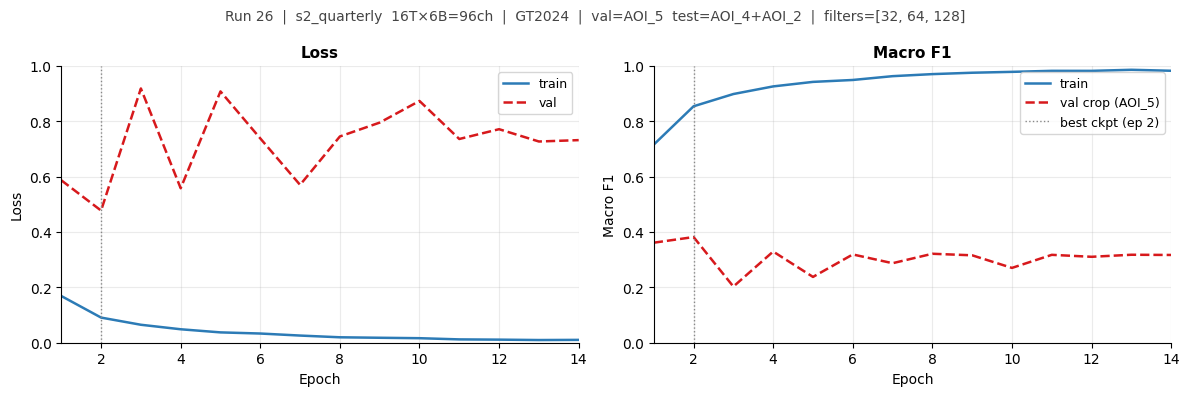

Plot saved → /content/exp/history_R35.png


In [ ]:
import matplotlib.pyplot as plt

h = history.history
def _k(base):
    for cand in [f'fus_{base}', base]:
        if cand in h: return cand
    raise KeyError(f'{base!r} not in history: {list(h.keys())}')
def _vk(base):
    for cand in [f'val_fus_{base}', f'val_{base}']:
        if cand in h: return cand
    return None

epochs_ran = range(1, len(h[_k('loss')]) + 1)
best_ep    = (np.argmax(h[_vk('custom_macro_f1_score')]) + 1) \
              if _vk('custom_macro_f1_score') else None

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(epochs_ran, h[_k('loss')], color='#2C7BB6', lw=1.8, label='train')
if _vk('loss'):
    ax.plot(epochs_ran, h[_vk('loss')], color='#D7191C', lw=1.8,
            linestyle='--', label='val')
if best_ep: ax.axvline(best_ep, color='#888', lw=1, linestyle=':')
ax.set_ylim(0, 1); ax.set_xlim(1, len(epochs_ran))
ax.set_title('Loss', fontsize=11, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(fontsize=9); ax.grid(alpha=0.25)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
ax.plot(epochs_ran, h[_k('custom_macro_f1_score')], color='#2C7BB6',
        lw=1.8, label='train')
if _vk('custom_macro_f1_score'):
    ax.plot(epochs_ran, h[_vk('custom_macro_f1_score')], color='#D7191C',
            lw=1.8, linestyle='--', label='val crop (AOI_5)')
if best_ep:
    ax.axvline(best_ep, color='#888', lw=1, linestyle=':',
               label=f'best ckpt (ep {best_ep})')
ax.set_ylim(0, 1); ax.set_xlim(1, len(epochs_ran))
ax.set_title('Macro F1', fontsize=11, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Macro F1')
ax.legend(fontsize=9); ax.grid(alpha=0.25)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle(
    f'Run 26  |  {TEMPORAL_RES}  {N_TIMESTEPS}T×{N_BANDS}B={TOTAL_CHANNELS}ch'
    f'  |  GT{GT_YEAR}  |  val=AOI_5  test=AOI_4+AOI_2  |  filters={filters}',
    fontsize=10, color='#444')
plt.tight_layout()
fig.savefig(os.path.join(EXP_DIR, 'history_R36.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved →', os.path.join(EXP_DIR, 'history_R36.png'))


## 11 · Validation Evaluation

Runs the best checkpoint over **all val AOIs in full** (no random crops) and computes:
- Confusion matrix (absolute pixel counts + row-normalised %)
- Per-class precision, recall, F1
- Overall accuracy on driver pixels only (bg/nodata excluded)

Weights loaded from /content/exp/checkpoint_R36.weights.h5

Full-AOI inference — VAL set
  AOI_2: 17,865 driver px  bark=0.39  mgmt=0.28  wind=1.00  (100.5s)

VAL — per-class report (17,865 driver px):
              precision    recall  f1-score   support

 bark-beetle      0.770     0.389     0.517     14044
        mgmt      0.405     0.277     0.329      3660
  wind-throw      0.019     1.000     0.038       161

    accuracy                          0.371     17865
   macro avg      0.398     0.555     0.295     17865
weighted avg      0.688     0.371     0.474     17865

  Overall accuracy: 0.371

Full-AOI inference — TEST set
  AOI_4: 6,558 driver px  bark=0.60  mgmt=0.02  wind=0.25  (99.7s)
  AOI_5: 19,555 driver px  bark=0.98  mgmt=0.00  wind=0.00  (98.4s)

TEST — per-class report (26,113 driver px):
              precision    recall  f1-score   support

 bark-beetle      0.833     0.930     0.879     21020
        mgmt      0.083     0.016     0.027      4085
  wind-throw     

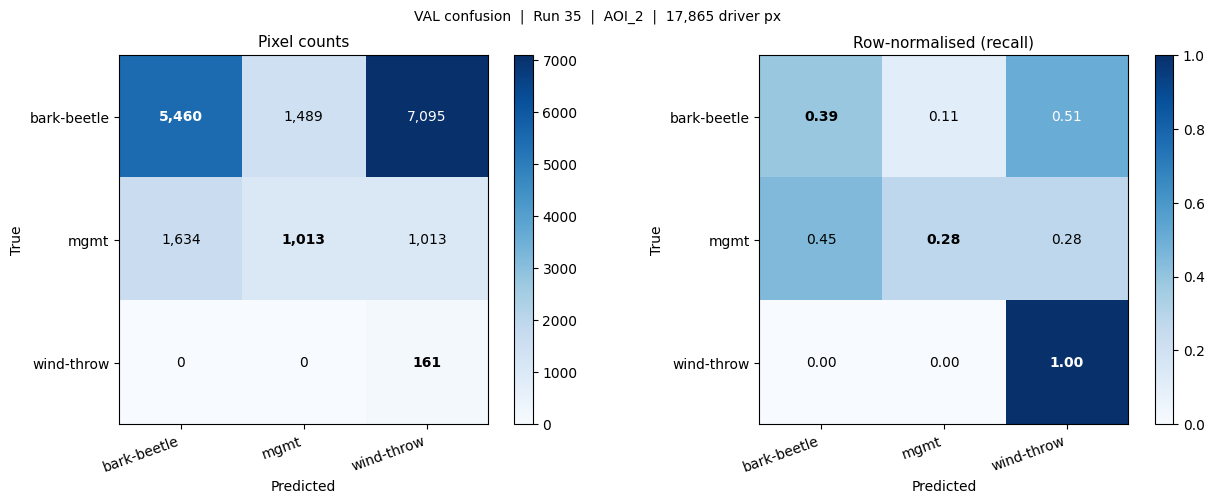

Saved → /content/exp/confusion_val_R36.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.metrics import confusion_matrix, classification_report

CLASS_NAMES = ['bark-beetle', 'mgmt', 'wind-throw']

# ── Load best checkpoint ──────────────────────────────────────────────────────
model.load_weights(ckpt_path)
print(f'Weights loaded from {ckpt_path}')

def predict_full_aoi(img_path, gt_path, tile=SIZE_CROPS):
    """Return (y_true, y_pred) flat arrays of driver pixels only (!=255)."""
    _s    = IMG_CACHE.get(img_path)
    stack = _s if _s is not None else np.load(img_path)
    _g    = GT_CACHE.get(gt_path)
    gt_orig = _g if _g is not None else np.load(gt_path)
    T, H, W, B = stack.shape
    ph = (tile - H % tile) % tile
    pw = (tile - W % tile) % tile
    stack_p = np.pad(stack, ((0,0),(0,ph),(0,pw),(0,0))) if (ph or pw) else stack
    Hp, Wp  = stack_p.shape[1], stack_p.shape[2]
    pred_map = np.zeros((Hp, Wp), dtype=np.uint8)
    for r in range(0, Hp, tile):
        for c in range(0, Wp, tile):
            crop     = stack_p[:, r:r+tile, c:c+tile, :]
            crop_img = crop.transpose(1,2,0,3).reshape(tile, tile, T*B)
            crop_img = crop_img[np.newaxis].astype(np.float32)
            logits   = model(crop_img, training=False)
            if isinstance(logits, dict): logits = next(iter(logits.values()))
            pred_map[r:r+tile, c:c+tile] = \
                np.argmax(logits[0].numpy(), axis=-1).astype(np.uint8)
    pred_map = pred_map[:H, :W]
    gt_crop  = gt_orig[:H, :W]
    mask     = gt_crop != 255
    return gt_crop[mask].astype(np.int32), pred_map[mask].astype(np.int32)

def _run_split_eval(imgs, gts, split_name):
    """Run full-AOI inference on a list of AOIs and print report."""
    # Leakage guard
    _train_keys = set(os.path.basename(p).replace('_input.npy','') for p in imgs_train)
    _eval_keys  = [os.path.basename(p).replace('_input.npy','') for p in imgs]
    _leaked     = [k for k in _eval_keys if k in _train_keys]
    if _leaked:
        raise RuntimeError(f'DATA LEAKAGE in {split_name}: {_leaked}')


    for ip, gp in zip(imgs, gts):
        if ip not in IMG_CACHE:
            IMG_CACHE[ip] = np.load(ip)
        if gp not in GT_CACHE:
            GT_CACHE[gp]  = np.load(gp)

    all_true, all_pred = [], []
    print(f'\n{"="*60}')
    print(f'Full-AOI inference — {split_name.upper()} set')
    print(f'{"="*60}')
    for img_p, gt_p in zip(imgs, gts):
        aoi = os.path.basename(img_p).replace('_input.npy', '')
        t0  = time.time()
        yt, yp = predict_full_aoi(img_p, gt_p)
        all_true.extend(yt.tolist())
        all_pred.extend(yp.tolist())
        per = {c: int((yp[yt==c]==c).sum())/max(1,int((yt==c).sum())) for c in range(3)}
        print(f'  {aoi}: {len(yt):,} driver px  '
              + '  '.join(f'{CLASS_NAMES[c][:4]}={per[c]:.2f}' for c in range(3))
              + f'  ({time.time()-t0:.1f}s)')

    yt_arr = np.array(all_true)
    yp_arr = np.array(all_pred)
    cm_s      = confusion_matrix(yt_arr, yp_arr, labels=[0,1,2])
    cm_norm_s = cm_s.astype(float) / cm_s.sum(axis=1, keepdims=True).clip(min=1)
    print(f'\n{split_name.upper()} — per-class report ({len(yt_arr):,} driver px):')
    print(classification_report(yt_arr, yp_arr, labels=[0,1,2],
                                 target_names=CLASS_NAMES, digits=3, zero_division=0))
    overall = int((yt_arr==yp_arr).sum()) / len(yt_arr)
    print(f'  Overall accuracy: {overall:.3f}')
    return yt_arr, yp_arr, cm_s, cm_norm_s

# ── VAL evaluation (AOI_5) ───────────────────────────────────────────────────
y_true, y_pred, cm, cm_norm = _run_split_eval(imgs_val, gt_val, 'val')

# ── TEST evaluation (AOI_4, AOI_2) — held-out ────────────────────────────────
if imgs_test:
    y_true_test, y_pred_test, cm_test, cm_norm_test = \
        _run_split_eval(imgs_test, gt_test, 'test')
    print('\n  TEST results above are the final held-out numbers.')
    print('   Do not tune hyperparameters based on these.')
else:
    print('No test AOIs defined.')

# ── Confusion matrix plot (val) ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, title, fmt, vmax in [
    (axes[0], cm,      'Pixel counts',            lambda v: f'{int(v):,}', None),
    (axes[1], cm_norm, 'Row-normalised (recall)',  lambda v: f'{v:.2f}',   1.0)]:
    im = ax.imshow(data, cmap='Blues', vmin=0, vmax=vmax)
    plt.colorbar(im, ax=ax)
    for i in range(3):
        for j in range(3):
            v = data[i,j]; thr = (vmax*0.5 if vmax else cm.max()*0.5)
            ax.text(j, i, fmt(v), ha='center', va='center', fontsize=10,
                    fontweight='bold' if i==j else 'normal',
                    color='white' if v>thr else 'black')
    ax.set_xticks(range(3)); ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right')
    ax.set_yticks(range(3)); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title, fontsize=11)
plt.suptitle(
    f'VAL confusion  |  Run 36  |  AOI_2  |  {len(y_true):,} driver px',
    fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(EXP_DIR, 'confusion_val_R36.png'), dpi=150)
plt.show()
print(f'Saved → {os.path.join(EXP_DIR, "confusion_val_R36.png")}')


In [ ]:
from sklearn.metrics import f1_score
import numpy as np

CLASS_NAMES = ['bark-beetle', 'mgmt', 'wind-throw']

def _summarise(yt, yp, split_name):
    macro   = f1_score(yt, yp, average='macro',    labels=[0,1,2], zero_division=0)
    weighted= f1_score(yt, yp, average='weighted', labels=[0,1,2], zero_division=0)
    per_cls = f1_score(yt, yp, average=None,       labels=[0,1,2], zero_division=0)
    print(f'\n── {split_name} F1 SUMMARY ──────────────────────────────')
    for i, (cls, f) in enumerate(zip(CLASS_NAMES, per_cls)):
        bar = '█' * int(f * 20)
        print(f'  {cls:<14} F1={f:.3f}  {bar}')
    print(f'  {"macro avg":<14} F1={macro:.3f}  ← primary metric')
    print(f'  {"weighted avg":<14} F1={weighted:.3f}')
    return macro

val_macro  = _summarise(y_true,      y_pred,      'VAL  (AOI_2)')
test_macro = _summarise(y_true_test, y_pred_test, 'TEST (AOI_4 + AOI_5)')

print(f'\n{"="*55}')
print(f'  VAL  macro F1 : {val_macro:.3f}')
print(f'  TEST macro F1 : {test_macro:.3f}')
print(f'{"="*55}')


── VAL  (AOI_2) F1 SUMMARY ──────────────────────────────
  bark-beetle    F1=0.517  ██████████
  mgmt           F1=0.329  ██████
  wind-throw     F1=0.038  
  macro avg      F1=0.295  ← primary metric
  weighted avg   F1=0.474

── TEST (AOI_4 + AOI_5) F1 SUMMARY ──────────────────────────────
  bark-beetle    F1=0.879  █████████████████
  mgmt           F1=0.027  
  wind-throw     F1=0.091  █
  macro avg      F1=0.332  ← primary metric
  weighted avg   F1=0.715

  VAL  macro F1 : 0.295
  TEST macro F1 : 0.332


In [ ]:

# path to the model for inference
KERAS_PATH   = '/content/drive/MyDrive/checkpoints/model_ep14.keras'
WEIGHTS_PATH = '/content/drive/MyDrive/checkpoints/weights_ep14.weights.h5'

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Requires: model, imgs_val, gt_val, imgs_test, gt_test,
#           imgs_train (for leakage guard), IMG_CACHE, GT_CACHE,
#           SIZE_CROPS, TOTAL_CHANNELS, N_BANDS, N_TIMESTEPS,
#           history, RUN_LABEL (or set manually below)
# ══════════════════════════════════════════════════════════════════════════════
import os, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_recall_fscore_support)

# ── identity ──────────────────────────────────────────────────────────────────
RUN_LABEL   = 'Run36_P2_s2q_3yr'   # name of the run for the outputs
REPORT_DIR  = os.path.join(EXP_DIR, 'run36_figures')
os.makedirs(REPORT_DIR, exist_ok=True)

CLASS_NAMES   = ['bark-beetle', 'mgmt', 'wind-throw']
CLASS_COLOURS = ['#D95F02', '#1B9E77', '#7570B3']
C_BG    = '#E8E8E8'
C_CORR  = '#2CA02C'
C_WRONG = '#D62728'

saved = []
def _save(fig, name):
    p = os.path.join(REPORT_DIR, name)
    fig.savefig(p, dpi=180, bbox_inches='tight')
    plt.close(fig)
    saved.append(p)
    print(f'  saved → {name}')
    return p

# ── inference helper ──────────────────────────────────────────────────────────
def _infer_aoi(img_path, gt_path):
    stack   = IMG_CACHE.get(img_path) #or np.load(img_path)
    gt_orig = GT_CACHE.get(gt_path)   #or np.load(gt_path)
    T, H, W, B = stack.shape
    flat = stack.transpose(1,2,0,3).reshape(H, W, T*B).astype(np.float32)
    ph = (SIZE_CROPS - H % SIZE_CROPS) % SIZE_CROPS
    pw = (SIZE_CROPS - W % SIZE_CROPS) % SIZE_CROPS
    if ph or pw:
        flat = np.pad(flat, ((0,ph),(0,pw),(0,0)))
    Hp, Wp = flat.shape[0], flat.shape[1]
    pm = np.zeros((Hp, Wp), dtype=np.uint8)
    for r in range(0, Hp, SIZE_CROPS):
        for c in range(0, Wp, SIZE_CROPS):
            crop   = flat[r:r+SIZE_CROPS, c:c+SIZE_CROPS,:][np.newaxis]
            logits = model(crop, training=False)
            if isinstance(logits, dict): logits = next(iter(logits.values()))
            pm[r:r+SIZE_CROPS, c:c+SIZE_CROPS] = \
                np.argmax(logits[0].numpy(), axis=-1).astype(np.uint8)
    pm = pm[:H, :W]
    mask = gt_orig[:H,:W] != 255
    return (gt_orig[:H,:W][mask].astype(np.int32),
            pm[mask].astype(np.int32),
            pm, gt_orig[:H,:W], stack)

# ── run inference on all splits ───────────────────────────────────────────────
print('Running full-AOI inference …')
_train_keys = set(os.path.basename(p).replace('_input.npy','') for p in imgs_train)

# cache test AOIs into RAM if needed
for ip, gp in zip(imgs_test, gt_test):
    if ip not in IMG_CACHE: IMG_CACHE[ip] = np.load(ip)
    if gp not in GT_CACHE:  GT_CACHE[gp]  = np.load(gp)

# per-AOI results store
aoi_data = {}   # {aoi: {yt, yp, pm, gt_map, stack, split}}

for split_imgs, split_gts, split_name in [
        (imgs_val,  gt_val,  'val'),
        (imgs_test, gt_test, 'test')]:
    for ip, gp in zip(split_imgs, split_gts):
        aoi = os.path.basename(ip).replace('_input.npy','')
        # leakage guard
        assert aoi not in _train_keys, f'LEAKAGE: {aoi} is in train!'
        t0 = time.time()
        yt, yp, pm, gt_map, stack = _infer_aoi(ip, gp)
        rc = {c: int((yp[yt==c]==c).sum())/max(1,int((yt==c).sum()))
              for c in range(3)}
        print(f'  {aoi} [{split_name}]  '
              + '  '.join(f'{CLASS_NAMES[c][:4]}={rc[c]:.2f}' for c in range(3))
              + f'  ({time.time()-t0:.1f}s)')
        aoi_data[aoi] = dict(yt=yt, yp=yp, pm=pm,
                              gt_map=gt_map, stack=stack, split=split_name)

# aggregate
yt_val  = np.concatenate([aoi_data[a]['yt'] for a in aoi_data if aoi_data[a]['split']=='val'])
yp_val  = np.concatenate([aoi_data[a]['yp'] for a in aoi_data if aoi_data[a]['split']=='val'])
yt_test = np.concatenate([aoi_data[a]['yt'] for a in aoi_data if aoi_data[a]['split']=='test'])
yp_test = np.concatenate([aoi_data[a]['yp'] for a in aoi_data if aoi_data[a]['split']=='test'])

# classification reports
rep_val  = classification_report(yt_val,  yp_val,  labels=[0,1,2],
                                  target_names=CLASS_NAMES, output_dict=True, zero_division=0)
rep_test = classification_report(yt_test, yp_test, labels=[0,1,2],
                                  target_names=CLASS_NAMES, output_dict=True, zero_division=0)
cm_val   = confusion_matrix(yt_val,  yp_val,  labels=[0,1,2])
cm_test  = confusion_matrix(yt_test, yp_test, labels=[0,1,2])

print(f'\nVal  macro F1 = {rep_val["macro avg"]["f1-score"]:.3f}')
print(f'Test macro F1 = {rep_test["macro avg"]["f1-score"]:.3f}')

# ══════════════════════════════════════════════════════════════════════════════
# FIG 1 · Dual confusion matrices  (val + test side by side)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f'Confusion matrices  |  {RUN_LABEL}', fontsize=12,
             fontweight='bold', y=0.98)

for col, (cm_raw, rep, split_lbl, aoi_lbl) in enumerate([
        (cm_val,  rep_val,  'VAL',  str([os.path.basename(p).replace('_input.npy','')
                                          for p in imgs_val])),
        (cm_test, rep_test, 'TEST', str([os.path.basename(p).replace('_input.npy','')
                                          for p in imgs_test]))]):
    cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1,keepdims=True).clip(min=1)
    for row, (data, title, fmt, vmax) in enumerate([
            (cm_raw,  f'{split_lbl} {aoi_lbl} — pixel counts',
             lambda v: f'{int(v):,}', None),
            (cm_norm, f'{split_lbl} — row-normalised (recall)',
             lambda v: f'{v:.2f}',   1.0)]):
        ax = axes[row, col]
        im = ax.imshow(data, cmap='Blues', vmin=0, vmax=vmax)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        for i in range(3):
            for j in range(3):
                v   = data[i,j]
                thr = (vmax*0.5 if vmax else cm_raw.max()*0.5)
                ax.text(j, i, fmt(v), ha='center', va='center',
                        fontsize=11 if row==1 else 9,
                        fontweight='bold' if i==j else 'normal',
                        color='white' if v>thr else '#222')
                if i==j:
                    ax.add_patch(plt.Rectangle(
                        (j-.5,i-.5), 1, 1, fill=False,
                        edgecolor=CLASS_COLOURS[i], lw=2.5))
        ax.set_xticks(range(3))
        ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right', fontsize=10)
        ax.set_yticks(range(3))
        ax.set_yticklabels(CLASS_NAMES, fontsize=10)
        ax.set_xlabel('Predicted', fontsize=9)
        ax.set_ylabel('True', fontsize=9)
        ax.set_title(title, fontsize=9, pad=6)

plt.tight_layout()
_save(fig, 'fig1_confusion_matrices.png')

# ══════════════════════════════════════════════════════════════════════════════
# FIG 2 · Per-class metrics bar chart  (prec / recall / F1 for val + test)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle(f'Per-class precision / recall / F1  |  {RUN_LABEL}',
             fontsize=11, fontweight='bold')

metrics_keys  = ['precision', 'recall', 'f1-score']
metrics_labels = ['Precision', 'Recall', 'F1']
x  = np.arange(len(metrics_keys))
wb = 0.26

for ax, rep, split_lbl in [(axes[0], rep_val, 'VAL'),
                             (axes[1], rep_test, 'TEST')]:
    for ci, (cls, col) in enumerate(zip(CLASS_NAMES, CLASS_COLOURS)):
        vals = [rep[cls][m] for m in metrics_keys]
        bars = ax.bar(x + (ci-1)*wb, vals, wb,
                      color=col, alpha=0.85, edgecolor='white',
                      label=cls)
        for bar, v in zip(bars, vals):
            if v > 0.04:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.015,
                        f'{v:.2f}', ha='center', fontsize=7.5,
                        color=col, fontweight='bold')
    # macro F1 line
    mf1 = rep['macro avg']['f1-score']
    ax.axhline(mf1, color='#2C3E50', lw=1.8, linestyle='-.',
               label=f'macro F1={mf1:.3f}')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_labels, fontsize=10)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_title(f'{split_lbl}  |  macro F1={mf1:.3f}'
                 f'  |  {len(yt_val if split_lbl=="VAL" else yt_test):,} driver px',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right', framealpha=0.9)
    ax.grid(axis='y', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
_save(fig, 'fig2_per_class_metrics.png')

# ══════════════════════════════════════════════════════════════════════════════
# FIG 3 · Per-AOI recall heatmap  (all AOIs, both splits)
# ══════════════════════════════════════════════════════════════════════════════
aoi_names, recall_rows, support_rows, split_labels = [], [], [], []
for split_name in ['val', 'test']:
    for aoi, d in aoi_data.items():
        if d['split'] != split_name:
            continue
        yt, yp = d['yt'], d['yp']
        rec = [int((yp[yt==c]==c).sum())/max(1,int((yt==c).sum()))
               for c in range(3)]
        sup = [int((yt==c).sum()) for c in range(3)]
        aoi_names.append(aoi)
        recall_rows.append(rec)
        support_rows.append(sup)
        split_labels.append(split_name.upper())

# aggregate rows
for agg_label, yt_agg, yp_agg in [
        (f'ALL VAL  (macro F1={rep_val["macro avg"]["f1-score"]:.3f})',
         yt_val, yp_val),
        (f'ALL TEST (macro F1={rep_test["macro avg"]["f1-score"]:.3f})',
         yt_test, yp_test)]:
    rec = [int((yp_agg[yt_agg==c]==c).sum())/max(1,int((yt_agg==c).sum()))
           for c in range(3)]
    sup = [int((yt_agg==c).sum()) for c in range(3)]
    aoi_names.append(agg_label)
    recall_rows.append(rec)
    support_rows.append(sup)
    split_labels.append('AGG')

rm = np.array(recall_rows)
sm = np.array(support_rows)
n_rows = len(aoi_names)

fig, ax = plt.subplots(figsize=(7, 0.72 * n_rows + 2.5))
im = ax.imshow(rm, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.06, pad=0.02, label='Recall')

for i, row_lbl in enumerate(aoi_names):
    for j in range(3):
        v = rm[i,j];  n = sm[i,j]
        bold = split_labels[i] == 'AGG'
        ax.text(j, i,
                f'{v:.2f}\n({int(n):,})',
                ha='center', va='center', fontsize=8.5,
                fontweight='bold' if bold else 'normal',
                color='white' if (v<0.25 or v>0.75) else '#222')

# separator lines between val / test / agg
boundaries = []
for idx in range(1, n_rows):
    if split_labels[idx] != split_labels[idx-1]:
        boundaries.append(idx - 0.5)
for b in boundaries:
    ax.axhline(b, color='#2C3E50', lw=2)

# left-side split labels
for i, (lbl, slbl) in enumerate(zip(aoi_names, split_labels)):
    colour = {'val': '#2166AC', 'VAL': '#2166AC',
              'TEST': '#B2182B', 'test': '#B2182B',
              'AGG': '#555'}.get(slbl, '#333')
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(aoi_names, fontsize=9)

ax.set_xticks(range(3))
ax.set_xticklabels(CLASS_NAMES, fontsize=10, fontweight='bold')
ax.set_title(f'Per-AOI recall  |  {RUN_LABEL}\n'
             f'Cell: recall  ·  (pixel count)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
_save(fig, 'fig3_per_aoi_recall_heatmap.png')

# ══════════════════════════════════════════════════════════════════════════════
# FIG 4 · Summary card  (training curves + per-class bars + confusion + config)
# ══════════════════════════════════════════════════════════════════════════════
h = history.history
def _hk(b):
    for c in [f'fus_{b}', b]:
        if c in h: return c
    return None
def _hvk(b):
    for c in [f'val_fus_{b}', f'val_{b}']:
        if c in h: return c
    return None

_tk_loss = _hk('loss');         _vk_loss = _hvk('loss')
_tk_f1   = _hk('custom_macro_f1_score')
_vk_f1   = _hvk('custom_macro_f1_score')
epochs_ran = range(1, len(h[_tk_loss])+1)
best_ep    = (np.argmax(h[_vk_f1])+1) if _vk_f1 else None

fig = plt.figure(figsize=(15, 8))
fig.patch.set_facecolor('#FAFAFA')
gs  = gridspec.GridSpec(2, 3, figure=fig,
                         left=0.06, right=0.97,
                         top=0.88,  bottom=0.08,
                         hspace=0.50, wspace=0.38)

# top-left: loss curves
ax0 = fig.add_subplot(gs[0,0])
ax0.plot(epochs_ran, h[_tk_loss], color='#2C7BB6', lw=1.8, label='train')
if _vk_loss:
    ax0.plot(epochs_ran, h[_vk_loss], color='#D7191C', lw=1.8,
             linestyle='--', label='val')
if best_ep: ax0.axvline(best_ep, color='#aaa', lw=1, linestyle=':')
ax0.set_title('Loss', fontsize=10, fontweight='bold')
ax0.set_xlabel('Epoch', fontsize=8); ax0.legend(fontsize=7.5)
ax0.grid(alpha=0.2); ax0.tick_params(labelsize=8)
ax0.spines['top'].set_visible(False); ax0.spines['right'].set_visible(False)

# top-centre: F1 curves
ax1 = fig.add_subplot(gs[0,1])
if _tk_f1:
    ax1.plot(epochs_ran, h[_tk_f1], color='#2C7BB6', lw=1.8, label='train')
if _vk_f1:
    ax1.plot(epochs_ran, h[_vk_f1], color='#D7191C', lw=1.8,
             linestyle='--', label='val (crops)')
    ax1.axhline(rep_val['macro avg']['f1-score'],
                color='#1B9E77', lw=1.6, linestyle='-.',
                label=f'§11 val F1={rep_val["macro avg"]["f1-score"]:.3f}')
    ax1.axhline(rep_test['macro avg']['f1-score'],
                color='#7570B3', lw=1.6, linestyle=':',
                label=f'§11 test F1={rep_test["macro avg"]["f1-score"]:.3f}')
ax1.set_ylim(0, 1.05)
ax1.set_title('Macro F1', fontsize=10, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=8); ax1.legend(fontsize=7)
ax1.grid(alpha=0.2); ax1.tick_params(labelsize=8)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# top-right: per-class F1 comparison val vs test
ax2 = fig.add_subplot(gs[0,2])
x2 = np.arange(3); wb2 = 0.32
for ci, (cls, col) in enumerate(zip(CLASS_NAMES, CLASS_COLOURS)):
    v_f1 = rep_val[cls]['f1-score']
    t_f1 = rep_test[cls]['f1-score']
    ax2.bar(ci - wb2/2, v_f1, wb2, color=col,   alpha=0.65, edgecolor='white',
            label='val' if ci==0 else '')
    ax2.bar(ci + wb2/2, t_f1, wb2, color=col,   alpha=1.00, edgecolor='white',
            hatch='////', label='test' if ci==0 else '')
    ax2.text(ci - wb2/2, v_f1+0.02, f'{v_f1:.2f}', ha='center',
             fontsize=7.5, color=col)
    ax2.text(ci + wb2/2, t_f1+0.02, f'{t_f1:.2f}', ha='center',
             fontsize=7.5, color=col, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels([c.replace('/',' /\n') for c in CLASS_NAMES], fontsize=8)
ax2.set_ylim(0, 1.15); ax2.set_ylabel('F1', fontsize=9)
ax2.set_title('Per-class F1  (light=val  dark=test)', fontsize=9, fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.2)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# bottom-left: normalised confusion matrix (test)
ax3 = fig.add_subplot(gs[1,0])
cm_t_norm = cm_test.astype(float)/cm_test.sum(axis=1,keepdims=True).clip(min=1)
im3 = ax3.imshow(cm_t_norm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
for i in range(3):
    for j in range(3):
        v = cm_t_norm[i,j]
        ax3.text(j, i, f'{v:.2f}', ha='center', va='center',
                 fontsize=10, fontweight='bold' if i==j else 'normal',
                 color='white' if v>0.5 else '#222')
        if i==j:
            ax3.add_patch(plt.Rectangle(
                (j-.5,i-.5), 1, 1, fill=False,
                edgecolor=CLASS_COLOURS[i], lw=2.2))
ax3.set_xticks(range(3)); ax3.set_xticklabels(CLASS_NAMES, rotation=15, fontsize=8)
ax3.set_yticks(range(3)); ax3.set_yticklabels(CLASS_NAMES, fontsize=8)
ax3.set_xlabel('Predicted', fontsize=8); ax3.set_ylabel('True', fontsize=8)
ax3.set_title('TEST confusion (recall-normalised)', fontsize=9, fontweight='bold')

# bottom-centre: per-AOI recall (compact heatmap without support numbers)
ax4 = fig.add_subplot(gs[1,1])
# only per-aoi rows, no aggregate
_rm_aoi = np.array([recall_rows[i] for i,l in enumerate(split_labels) if l!='AGG'])
_an_aoi = [n for n,l in zip(aoi_names, split_labels) if l!='AGG']
_sl_aoi = [l for l in split_labels if l!='AGG']
im4 = ax4.imshow(_rm_aoi, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
for i, (row, sl) in enumerate(zip(_an_aoi, _sl_aoi)):
    for j in range(3):
        v = _rm_aoi[i,j]
        ax4.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                 color='white' if (v<0.25 or v>0.75) else '#222')
# separator between val and test rows
for idx in range(1, len(_sl_aoi)):
    if _sl_aoi[idx] != _sl_aoi[idx-1]:
        ax4.axhline(idx-0.5, color='#333', lw=2)
ax4.set_xticks(range(3))
ax4.set_xticklabels(CLASS_NAMES, fontsize=8, rotation=15)
ax4.set_yticks(range(len(_an_aoi)))
ax4.set_yticklabels(_an_aoi, fontsize=8)
ax4.set_title('Per-AOI recall', fontsize=9, fontweight='bold')

# bottom-right: config table
ax5 = fig.add_subplot(gs[1,2])
ax5.axis('off')
_cfg = [
    ['Run',            RUN_LABEL],
    ['TEMPORAL_RES',   TEMPORAL_RES],
    ['GT_YEAR',        str(GT_YEAR)],
    ['N_TIMESTEPS',    str(N_TIMESTEPS)],
    ['TOTAL_CHANNELS', str(TOTAL_CHANNELS)],
    ['N_SAMPLES_TRAIN',str(N_SAMPLES_TRAIN)],
    ['EPOCHS trained', str(len(epochs_ran))],
    ['TEMPERATURE',    str(TEMPERATURE)],
    ['WT_OVERSAMPLE',  str(WIND_THROW_OVERSAMPLE)],
    ['WEIGHT_DECAY',   str(WEIGHT_DECAY)],
    ['Filters',        str(filters)],
    ['Val macro F1',   f'{rep_val["macro avg"]["f1-score"]:.3f}'],
    ['Test macro F1',  f'{rep_test["macro avg"]["f1-score"]:.3f}'],
    ['Test accuracy',  f'{(yt_test==yp_test).mean():.3f}'],
]
tbl = ax5.table(cellText=_cfg, colLabels=['Parameter','Value'],
                cellLoc='left', loc='center', bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(8)
for j in range(2):
    tbl[0,j].set_facecolor('#2C3E50')
    tbl[0,j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(_cfg)+1):
    bg = '#F5F5F5' if i%2==0 else 'white'
    if _cfg[i-1][0] in ('Val macro F1','Test macro F1','Test accuracy'):
        bg = '#D5E8D4'
    for j in range(2):
        tbl[i,j].set_facecolor(bg)
ax5.set_title('Run configuration', fontsize=9, fontweight='bold', pad=8)

fig.suptitle(f'Run summary  |  {RUN_LABEL}', fontsize=12,
             fontweight='bold', color='#2C3E50', y=0.96)
_save(fig, 'fig4_summary_card.png')

# ── copy to Drive ─────────────────────────────────────────────────────────────
import shutil
drive_report = os.path.join(DRIVE_ROOT, f'run_reports/{RUN_LABEL}')
shutil.copytree(REPORT_DIR, drive_report, dirs_exist_ok=True)
print(f'\n✓ All figures saved to {REPORT_DIR}  and  {drive_report}')
for p in saved:
    print(f'  {os.path.basename(p):45}  {os.path.getsize(p)//1024} KB')

Running full-AOI inference …
  AOI_2 [val]  bark=0.39  mgmt=0.28  wind=1.00  (103.7s)
  AOI_4 [test]  bark=0.60  mgmt=0.02  wind=0.25  (98.4s)
  AOI_5 [test]  bark=0.98  mgmt=0.00  wind=0.00  (98.3s)

Val  macro F1 = 0.295
Test macro F1 = 0.332
  saved → fig1_confusion_matrices.png
  saved → fig2_per_class_metrics.png
  saved → fig3_per_aoi_recall_heatmap.png
  saved → fig4_summary_card.png

✓ All figures saved to /content/exp/run36_figures  and  /content/drive/MyDrive/run_reports/Run36_P2_s2q_3yr
  fig1_confusion_matrices.png                    198 KB
  fig2_per_class_metrics.png                     83 KB
  fig3_per_aoi_recall_heatmap.png                99 KB
  fig4_summary_card.png                          257 KB


In [ ]:
from google.colab import runtime
runtime.unassign()